In [1]:
# Cell 1 — install the packages used in this notebook
!pip install requests matplotlib numpy scipy -q

# **Ising Calibration Agent with NVIDIA AI Foundation Models**

[**build.nvidia.com**](https://build.nvidia.com/) offers **NVIDIA Inference Microservices (NIM)**,
allowing developers to experience state-of-the-art models accelerated on NVIDIA GPUs anywhere.
One of them is [**NVIDIA Ising Calibration 1**](https://build.nvidia.com/nvidia/ising-calibration-1-35b-a3b) —
a vision-language model (VLM) that reads **quantum-calibration plots** the way an experimentalist does.

In this warm-up you will:

1. **Open the Ising Calibration playground** at
   [build.nvidia.com/nvidia/ising-calibration-1-35b-a3b](https://build.nvidia.com/nvidia/ising-calibration-1-35b-a3b)
   and try the browser chat.
2. **Examine a calibration plot** (`calibration_example.png`, or one you generated yourself).
3. **Query the agent with your data** — attach the plot and ask it to explain the results.
4. Later, **simulate your own calibration tests** with the CUDA-Q dynamics API in the
   optional **Appendix** at the end of this notebook and bring those plots back here.

Sign up for free credits on [build.nvidia.com](https://build.nvidia.com/), generate an API key,
and paste it into the following cell:

In [2]:
# Cell 2 — set your build.nvidia.com API key
import os

# api_key = "Paste your API key here (must include prefix: nvapi-)"
api_key = "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"

if api_key.startswith("nvapi-"):
    os.environ["NVIDIA_API_KEY"] = api_key
api_key = os.environ.get("NVIDIA_API_KEY", api_key)

if api_key.startswith("nvapi-"):
    print("API key set.")
else:
    print("No valid key yet — the query cells below will print instructions instead of answers.")

API key set.


### Part I: Meet the model

**NVIDIA Ising Calibration 1** (`nvidia/ising-calibration-1-35b-a3b`) is an open-weight
mixture-of-experts vision-language model built on Qwen3.5-35B-A3B and fine-tuned for quantum
calibration plot understanding. It was released with **QCalEval**
([arXiv:2604.25884](https://arxiv.org/abs/2604.25884)), the first benchmark for this task —
243 samples across 22 experiment families spanning superconducting qubits and neutral atoms —
where it reaches the top zero-shot mean score (74.7).

This tutorial will go through **six question types**, and the VLM will answer all of them.
Phrasing your prompts in these styles plays to its strengths:

| # | Question type | What you ask |
|---|---|---|
| Q1 | Technical description | describe the plot type, axes, salient features |
| Q2 | Experimental conclusion | classify: Expected behavior / Suboptimal parameters / Anomalous behavior / Apparatus issue |
| Q3 | Experimental significance | what the pattern implies; is the sweep sufficient; what calibration step follows |
| Q4 | Fit reliability | is the overlaid fit Reliable / Unreliable / No fit |
| Q5 | Parameter extraction | machine-readable JSON of physical parameters |
| Q6 | Calibration diagnosis | a status code (e.g. `SUCCESS`, `NO_SIGNAL`, `AMP_TOO_HIGH`) plus corrective action |

### Part II: Get a calibration plot to analyze

The VLM needs an experiment image — here, **resonator spectroscopy**, the *very first*
measurement of any bring-up: before you can even see the qubit, you must find the **readout
resonator** it is coupled to.

The resonator is a harmonic oscillator with frequency $f_r$ and linewidth $\kappa$ (photon
loss). Sweep a weak probe tone across the expected band and record the transmitted magnitude
$|S_{21}|$: on resonance the resonator absorbs the probe, so it reveals itself as a **narrow
dip** at $f_r$ — the dip width is $\kappa$ — and a Lorentzian fit reports the frequency with
its uncertainty, exactly how the plot comes out of a real lab stack.

You are encouraged to run the optional **Appendix** below (a CUDA-Q dynamics simulation of
this driven, damped cavity) — its resonator plot is used here. Take a moment to read the plot
yourself before asking the agent: where is the dip, how wide is it, is the signal usable?

using: calibration_plots/resonator_spectroscopy.png


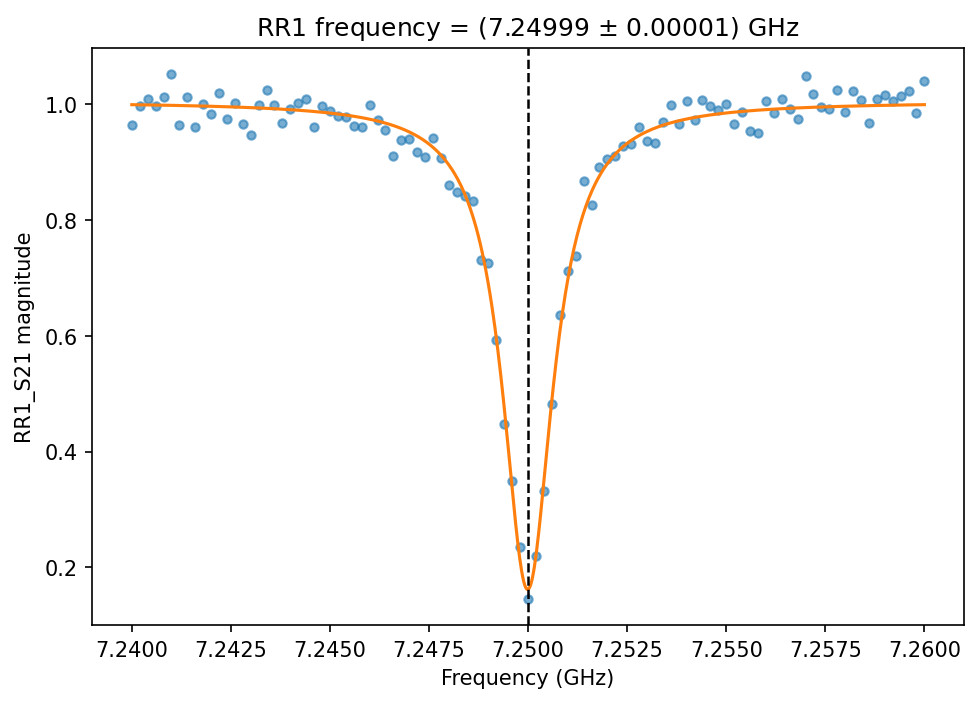

In [3]:
# Cell 3 — load a CUDA-Q-generated plot if available, else synthesize an example
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from IPython.display import Image, display

plot_path = "calibration_plots/resonator_spectroscopy.png"   # from Appendix A.2

if not os.path.exists(plot_path):
    # A stand-in: resonator spectroscopy as it comes out of a lab stack — a
    # narrow dip in |S21|, a Lorentzian fit, and the frequency +/- error.
    rng = np.random.default_rng(7)
    freqs = np.linspace(7.240, 7.260, 101)               # probe frequency (GHz)
    f_r, hwhm = 7.250, 0.00075                           # dip center and half width
    dip = hwhm**2 / ((freqs - f_r)**2 + hwhm**2)
    s21 = 1.0 - 0.85 * dip                               # the resonator absorbs on resonance
    s21_meas = s21 + rng.normal(0.0, 0.02, size=freqs.size)

    def lorentzian_dip(f, offset, depth, f0, w):
        return offset - depth * w**2 / ((f - f0)**2 + w**2)

    popt, pcov = curve_fit(lorentzian_dip, freqs, s21_meas,
                           p0=[1.0, 0.85, freqs[np.argmin(s21_meas)], 0.001])
    f0_fit = popt[2]
    f0_err = np.sqrt(np.diag(pcov))[2]

    f_fine = np.linspace(freqs[0], freqs[-1], 800)
    fig, ax = plt.subplots(figsize=(7.5, 5))
    ax.scatter(freqs, s21_meas, s=16, alpha=0.6)
    ax.plot(f_fine, lorentzian_dip(f_fine, *popt), color="tab:orange")
    ax.axvline(f0_fit, color="black", linestyle="--", linewidth=1.2)
    ax.set_xlabel("Frequency (GHz)")
    ax.set_ylabel("RR1_S21 magnitude")
    ax.set_title(f"RR1 frequency = ({f0_fit:.5f} $\\pm$ {f0_err:.5f}) GHz")
    os.makedirs("calibration_plots", exist_ok=True)
    plot_path = "calibration_plots/calibration_example.png"
    fig.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

print(f"using: {plot_path}")
display(Image(filename=plot_path))

### Part III: Describe the plot, then ask for the conclusion

The agent answers over the NVIDIA LLM API gateway at `https://integrate.api.nvidia.com/v1`
— the plot travels as a base64 `image_url`, and the model card recommends `temperature=0`.
The helper below wraps one request, then asks the first two question types in order: **Q1**
(technical description — the benchmark's universal prompt: describe the plot as structured
JSON before interpreting it) and **Q2** (experimental conclusion — the 4-way outcome
classification).

In [4]:
# Cell 4 — one helper, then Q1 (describe) and Q2 (conclude) on the plot
import base64
import requests

invoke_url = "https://integrate.api.nvidia.com/v1/chat/completions"
model_id = "nvidia/ising-calibration-1-35b-a3b"

def ask_agent(image_path, question, max_tokens=1024):
    # Send one calibration plot + one question to the Ising Calibration agent.
    key = os.environ.get("NVIDIA_API_KEY", "")
    if not key.startswith("nvapi-"):
        return ("[no NVIDIA_API_KEY set — paste your key in Cell 2 and re-run; "
                "get one free at https://build.nvidia.com/nvidia/ising-calibration-1-35b-a3b]")
    with open(image_path, "rb") as f:
        image_b64 = base64.b64encode(f.read()).decode()
    payload = {
        "model": model_id,
        "temperature": 0,               # the model card's recommended setting
        "max_tokens": max_tokens,
        "messages": [{
            "role": "user",
            "content": [
                {"type": "text", "text": question},
                {"type": "image_url",
                 "image_url": {"url": f"data:image/png;base64,{image_b64}"}},
            ],
        }],
    }
    headers = {"Authorization": f"Bearer {key}", "Accept": "application/json"}
    response = requests.post(invoke_url, headers=headers, json=payload, timeout=300)
    if response.status_code != 200:
        return f"[request failed ({response.status_code}): {response.text}]"
    return response.json()["choices"][0]["message"]["content"]

# Q1 — technical description: the benchmark's universal prompt, same for every
# experiment family. Pure visual grounding, no interpretation yet.
q1_question = (
    "Describe this plot as JSON with fields: plot_type, x_axis, y_axis, "
    "main_features."
)
print("=== Q1 - technical description ===")
print(ask_agent(plot_path, q1_question))

# Q2 — experimental conclusion: the 4-way outcome classification.
q2_question = (
    "This is a resonator spectroscopy measurement of a superconducting readout "
    "resonator: transmitted |S21| magnitude vs. probe frequency, where the "
    "resonator appears as a dip. Classify the outcome as Expected behavior / "
    "Suboptimal parameters / Anomalous behavior / Apparatus issue, and explain "
    "the reasoning from the visible features."
)
print("\n=== Q2 - experimental conclusion ===")
print(ask_agent(plot_path, q2_question))

=== Q1 - technical description ===




```json
{
  "plot_type": "2D line plot with scatter points",
  "x_axis": "Frequency (GHz)",
  "y_axis": "RR1_S21 magnitude",
  "main_features": [
    "The plot displays a transmission resonance dip for a resonator labeled 'RR1'.",
    "Blue dots represent experimental data points showing the S21 magnitude versus frequency.",
    "An orange curve is fitted to the data, modeling the resonance dip.",
    "A vertical dashed black line indicates the center frequency of the resonance.",
    "The title reports the fitted frequency as 7.24999 ± 0.00001 GHz.",
    "The resonance depth is significant, dropping from a baseline magnitude of ~1.0 to a minimum of ~0.15."
  ]
}
```

=== Q2 - experimental conclusion ===




**Classification:** Expected behavior

**Reasoning:**
The plot displays a textbook example of a resonator spectroscopy measurement. The data points (blue dots) form a clean, symmetric dip in the transmission magnitude ($|S_{21}|$), which is the characteristic signature of a resonant mode. The orange curve represents a high-quality fit (likely a Lorentzian or similar resonant function) that tracks the experimental data very closely, indicating a robust signal-to-noise ratio. Furthermore, the title reports a precise resonant frequency ($7.24999 \pm 0.00001$ GHz), confirming that the fitting algorithm successfully converged on the physical parameters of the system. There are no signs of distortion, multiple modes, or poor fitting that would suggest suboptimal parameters or apparatus issues.


### Part IV: Significance, fit reliability, parameters, and a diagnosis

One plot may induces many questions. The four below cover the remaining QCalEval formats the
agent was trained on: **Q3** (significance — *what does it mean and what should I calibrate
next?*), **Q4** (fit reliability — is the overlaid curve trustworthy: Reliable / Unreliable /
No fit), **Q5** (parameter extraction as machine-readable JSON, in the benchmark's schema
style for this experiment family), and **Q6** (an operational status code). Q5-style answers
are what an automated calibration loop would parse and feed back into the experiment stack.
Together with Q1 and Q2 above, all **six QCalEval question types** now run on this plot.

In [5]:
# Cell 5 — the remaining question types (Q3, Q4, Q5, Q6) on the same plot
followups = {
    "Q3 - experimental significance": (
        "Explain what this resonator spectroscopy plot implies about the device: "
        "is the resonance well resolved, what does the dip width say about the "
        "resonator linewidth kappa, whether the sweep window and resolution were "
        "sufficient, and what the next calibration step should be."
    ),
    "Q4 - fit reliability": (
        "A fitted curve is overlaid on the measured data points in this resonator "
        "spectroscopy plot. Assess whether the fit is trustworthy for parameter "
        "extraction: Reliable, Unreliable, or No fit — and justify the assessment "
        "from the plot."
    ),
    "Q5 - parameter extraction": (
        "Extract from this resonator spectroscopy plot as JSON: "
        '{"f_r_MHz": float, "linewidth_kappa_MHz": float, "dip_visible": bool, '
        '"measurement_usable": bool}.'
    ),
    # AMP_TOO_HIGH from Part I is a qubit-spectroscopy status; a resonator scan
    # chooses from the two that apply here.
    "Q6 - calibration diagnosis": (
        "Assign this resonator spectroscopy result a status from {SUCCESS, "
        "NO_SIGNAL} and, if not SUCCESS, suggest the corrective action."
    ),
}

for name, q in followups.items():
    print(f"=== {name} ===")
    print(ask_agent(plot_path, q))
    print()

=== Q3 - experimental significance ===


The user wants me to analyze a resonator spectroscopy plot.

**1. Analyze the plot:**
*   **X-axis:** Frequency in GHz, ranging from roughly 7.2400 to 7.2600.
*   **Y-axis:** RR1_S21 magnitude, ranging from roughly 0.1 to 1.05.
*   **Data points:** Blue dots representing measured data.
*   **Fit:** An orange curve fitted to the data, showing a Lorentzian-like dip.
*   **Resonance:** There is a clear, sharp dip in the transmission magnitude (S21).
*   **Resonant Frequency:** The dip is centered at approximately 7.2500 GHz. The title explicitly states `RR1 frequency = (7.24999 ± 0.00001) GHz`.
*   **Dip Depth:** The dip goes down to about 0.15, which is quite deep, indicating good coupling or a high quality factor relative to the background.
*   **Dip Width:** The dip is very narrow. Looking at the x-axis, the full width at half maximum (FWHM) seems to be roughly 0.002 - 0.003 GHz (2-3 MHz). This is a relatively narrow linewidth for a superconducting resonator, suggesting a high Q-factor



**Assessment:** Reliable

**Justification:** The orange fitted curve closely tracks the blue data points across the entire frequency range, accurately capturing the characteristic Lorentzian dip of the resonator. The fit aligns perfectly with the baseline and the minimum of the resonance, indicating a high-quality model that reliably represents the underlying physical data for parameter extraction.

=== Q5 - parameter extraction ===


Based on the provided spectroscopy plot:

- The resonance frequency $f_r$ is clearly marked by the vertical dashed line and the title: **7.24999 GHz**, which is **7249.99 MHz**.
- The dip is very sharp and well-defined, indicating a high-Q resonator. The linewidth $\kappa$ (full width at half minimum) can be estimated from the plot. The dip goes from ~1.0 to ~0.15, so half-minimum is around 0.575. Looking at the x-axis, the width at that level is approximately from 7.2498 to 7.2502 GHz — about 0.0004 GHz = **0.4 MHz**. This is consistent with a narrow linewidth for a superconducting qubit readout resonator.
- The dip is clearly visible — yes.
- The measurement is usable — yes, the data points follow the fitted curve well, and the resonance is clean.

Thus, the extracted values are:

```json
{"f_r_MHz": 7249.99, "linewidth_kappa_MHz": 0.4, "dip_visible": true, "measurement_usable": true}
```

=== Q6 - calibration diagnosis ===


Based on the provided spectroscopy plot, here is the analysis:

**Status:** SUCCESS

**Reasoning:**
The plot displays a clear, high-contrast resonance dip in the RR1 S21 magnitude, which is characteristic of a well-coupled superconducting resonator. The data points (blue dots) follow a distinct Lorentzian-like shape, and the orange fit line accurately models the resonance. The title explicitly states a precise frequency determination ($7.24999 \pm 0.00001$ GHz) with a very small uncertainty, confirming that the resonator was successfully identified and characterized. There are no signs of noise overwhelming the signal or a missing resonance feature.



### Part V: Case study — a drifting resonator (can the agent catch it?)

So far the agent has only seen a *healthy* measurement. Real resonators do not sit still:
the fridge stage warms by a millikelvin, two-level-system defects switch, and $f_r$ wanders —
a calibration that was perfect an hour ago silently goes stale. That is why calibration is a
loop, not a one-time setup, and exactly the failure mode agents like Ising Calibration 1 are
meant to catch. The standard detection is simple: **repeat the scan and compare**.

Below, the same resonator is scanned twice a few minutes apart, and the dip lands about
4 MHz — roughly three linewidths — higher the second time. We hand the two-dip plot to the
agent with an open question, no status list and no hints: is this device stable, what could
cause it, and how should a system with this kind of error be calibrated? (This cell synthesizes
the scenario if the plot is not already on disk, mirroring Cell 3.)

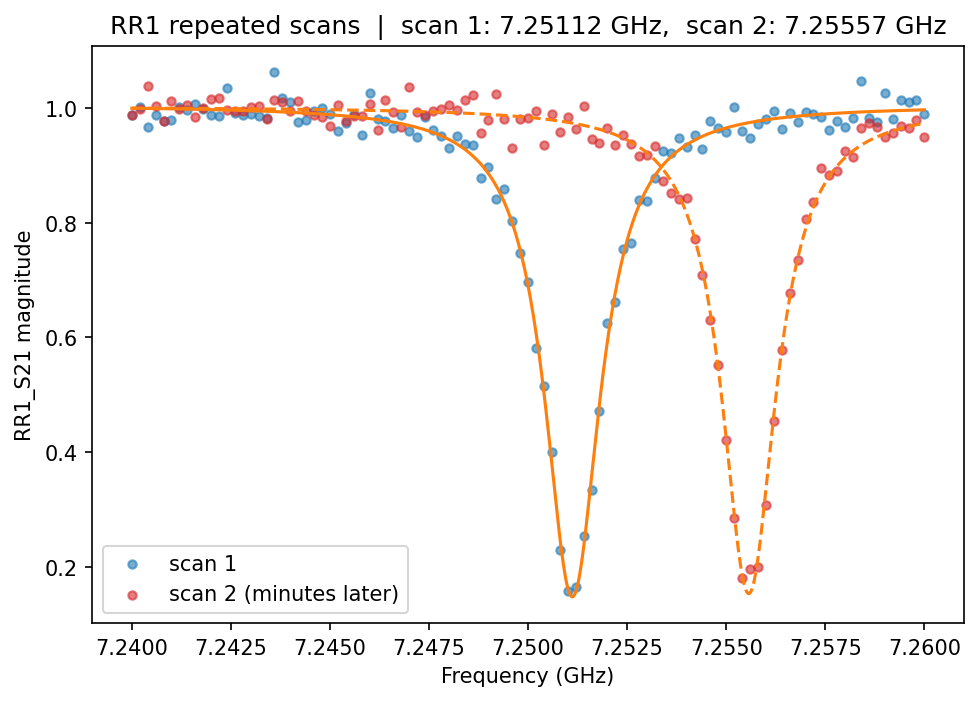



Based on the provided spectroscopy plots, here is my analysis of the device behavior and recommended next steps.

### Diagnosis: Resonator Frequency Instability

The most critical observation is that the resonator frequency is **not stable**.

*   **Scan 1 (Blue):** The resonance dip is centered at approximately **7.25112 GHz**.
*   **Scan 2 (Red):** The resonance dip has shifted to approximately **7.25557 GHz**.

This represents a frequency drift of roughly **4.45 MHz** between two scans taken only minutes apart. In the context of superconducting qubit readout, where resonators are typically high-Q (high quality factor) and narrow, a shift of this magnitude is significant. It indicates that the resonator's physical properties (capacitance or inductance) are changing over time


In [6]:
# Cell 6 — the drift case: two scans of the same resonator, then ask the agent
drift_path = "calibration_plots/resonator_drift.png"     # synthesized below if absent

if not os.path.exists(drift_path):
    # Stand-in: the same two-scan session, synthesized analytically — the
    # resonator sits ~4 MHz higher by the time the scan is repeated.
    rng2 = np.random.default_rng(11)
    dfreqs = np.linspace(7.240, 7.260, 101)              # probe frequency (GHz)
    hwhm = 0.00075                                       # half linewidth
    dip1 = hwhm**2 / ((dfreqs - 7.2510)**2 + hwhm**2)
    dip2 = hwhm**2 / ((dfreqs - 7.2550)**2 + hwhm**2)
    s21_scan1 = 1.0 - 0.85 * dip1 + rng2.normal(0.0, 0.02, dfreqs.size)
    s21_scan2 = 1.0 - 0.85 * dip2 + rng2.normal(0.0, 0.02, dfreqs.size)

    def lorentzian_dip(f, offset, depth, f0, w):
        return offset - depth * w**2 / ((f - f0)**2 + w**2)

    popt1, _ = curve_fit(lorentzian_dip, dfreqs, s21_scan1,
                         p0=[1.0, 0.85, dfreqs[np.argmin(s21_scan1)], 0.001])
    popt2, _ = curve_fit(lorentzian_dip, dfreqs, s21_scan2,
                         p0=[1.0, 0.85, dfreqs[np.argmin(s21_scan2)], 0.001])

    f_fine = np.linspace(dfreqs[0], dfreqs[-1], 800)
    fig, ax = plt.subplots(figsize=(7.5, 5))
    ax.scatter(dfreqs, s21_scan1, s=16, alpha=0.6, label="scan 1")
    ax.scatter(dfreqs, s21_scan2, s=16, alpha=0.6, color="tab:red",
               label="scan 2 (minutes later)")
    ax.plot(f_fine, lorentzian_dip(f_fine, *popt1), color="tab:orange")
    ax.plot(f_fine, lorentzian_dip(f_fine, *popt2), color="tab:orange", linestyle="--")
    ax.set_xlabel("Frequency (GHz)")
    ax.set_ylabel("RR1_S21 magnitude")
    ax.set_title(f"RR1 repeated scans  |  scan 1: {popt1[2]:.5f} GHz,  "
                 f"scan 2: {popt2[2]:.5f} GHz")
    ax.legend()
    fig.savefig(drift_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

display(Image(filename=drift_path))

# the diagnosis: an open question, not a fixed status list
drift_question = (
    "These are two consecutive resonator spectroscopy scans of the same readout "
    "resonator RR1, taken a few minutes apart (blue: scan 1, red: scan 2; the "
    "orange curves are Lorentzian fits). Diagnose the device: is the resonator "
    "frequency stable? What could cause this behavior, and what calibration "
    "strategy would you recommend for operating a system with this kind of error?"
)
print(ask_agent(drift_path, drift_question))

### Part VI: Bring your own experiments

You have the full loop now: *plot in, expert reading out*. Two ways to go further:

- **Generate real simulated data.** Continue into the optional **Appendix** below — it uses
  the **CUDA-Q dynamics API** to simulate the full bring-up chain (resonator spectroscopy,
  qubit spectroscopy, Rabi, $T_1$, Ramsey), one explained experiment per section, saving
  five agent-ready plots into `calibration_plots/`. Re-run the `ask_agent(...)` cells above on
  each of them — the Rabi plot with a Q4 *fit reliability* question is a good one.
- **Try the browser playground.** The same model runs interactively at
  [build.nvidia.com/nvidia/ising-calibration-1-35b-a3b](https://build.nvidia.com/nvidia/ising-calibration-1-35b-a3b)
  — attach a plot and chat, no code required.

The most interesting experiments are the *broken* ones. Edit the parameters in the Appendix
cells, regenerate, and see whether the agent catches each failure:

- **`NO_SIGNAL`** — sweep `res_freqs` over `7.30–7.32` GHz in A.2 (or the qubit `freqs` over
  `4.20–4.50` GHz in A.3) so the resonance sits outside the window.
- **`AMP_TOO_HIGH`** — crank `omega_probe` to `0.10` in A.3 so the qubit line power-broadens
  further and the two-photon $f_{02}/2$ dip at 4.690 GHz grows in.
- **Dying qubit** — set `T1 = 3000` ns *and* `T2_star = 4000` ns in A.1 (keep
  $T_2^* \le 2T_1$, or the pure-dephasing rate turns negative) and ask what the agent would
  recalibrate first.

That closed loop — *simulate → plot → let an agent read it → act* — is exactly the automated
calibration workflow the QCalEval paper is building toward. ✨

---

## Appendix (optional) — simulate the calibration experiments yourself

The CUDA-Q versions of the plots the agent has been reading are produced here, with
the **CUDA-Q dynamics API** — the
GPU-accelerated Lindblad master-equation solver behind `cudaq.set_target("dynamics")`. This
appendix contains the five bring-up experiments behind those plots — plus an open
exercise (A.7) — one per section and in **real
bring-up order**, so you can tweak a parameter, regenerate a plot, and immediately test the
agent on it (each cell overwrites its PNG in `calibration_plots/`; just re-run the
`ask_agent(...)` cells above, or point them at a different file).

Three modeling conventions used throughout:

- **Rotating frame** — instead of simulating a GHz carrier, we work in the frame rotating at
  the drive/probe frequency, where only MHz-scale detunings and amplitudes remain. Same
  physics, thousands of times fewer integration steps.
- **Units** — time in **ns**, frequency in **GHz**, every Hamiltonian coefficient carries an
  explicit $2\pi$ (angular frequency).
- **Finite measurement** — exact populations are turned into 1000-shot binomial estimates
  (and spectroscopy signals get analog readout noise), so the fits face realistic data.

Requirements: CUDA-Q and one NVIDIA GPU (the bootcamp environment has both). On an idle
GPU the whole appendix runs in about a minute; the batched spectroscopy sweeps dominate,
and can take several minutes each if the GPU is shared with other jobs.

### A.1 · Setup — the virtual device

We fix the device's *true* parameters up front — the whole point of a virtual device is that
every fit below can be checked against a known answer:

| Parameter | Symbol | Value |
|---|---|---|
| Qubit transition frequency | $f_{01}$ | $4.800$ GHz |
| Anharmonicity | $\alpha$ | $-220$ MHz (so the two-photon line sits at $f_{02}/2 = 4.690$ GHz) |
| Energy relaxation time | $T_1$ | $25\ \mu s$ |
| Ramsey dephasing time | $T_2^*$ | $10\ \mu s$ |

(The readout resonator's $f_r = 7.250$ GHz and linewidth $\kappa = 1.5$ MHz are defined in
A.2.) The ladder operators $\hat a$, $\hat a^\dagger$, $\hat N$ are dimension-agnostic — the
Hilbert-space size is set per experiment by the `dimensions` map handed to `cudaq.evolve`.

In [7]:
# Cell A1 — appendix setup: the dynamics target, the virtual device, helpers
import time
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore")     # some environments emit a harmless CuPy
    import cudaq                        # install warning at import time
from cudaq import operators, spin, RungeKuttaIntegrator
from cudaq.dynamics import Schedule, InitialState

cudaq.set_target("dynamics")            # GPU master-equation solver
cudaq.set_random_seed(1234)

# the virtual device: the ground truth every experiment must re-discover
f01_true = 4.800                     # GHz   qubit transition frequency
alpha = -0.220                       # GHz   anharmonicity (f12 - f01)
f02_half = f01_true + alpha / 2.0    # GHz   two-photon line at 4.690
T1 = 25000.0                         # ns    energy relaxation time (25 us)
T2_star = 10000.0                    # ns    Ramsey dephasing time  (10 us)
gamma_phi = 1.0 / T2_star - 1.0 / (2.0 * T1)     # 1/ns  pure dephasing rate

shots = 1000
rng = np.random.default_rng(1234)

def measure(populations):
    """Turn exact populations into 1000-shot estimates, like a real readout."""
    return rng.binomial(shots, np.clip(populations, 0.0, 1.0)) / shots

plot_dir = "calibration_plots"
os.makedirs(plot_dir, exist_ok=True)

# ladder operators — dimension-agnostic; the Hilbert-space size is set by the
# dimensions map handed to each evolve call
a = operators.annihilate(0)
a_dag = operators.create(0)
N = operators.number(0)

def lorentzian_dip(f, offset, depth, f0, hwhm):
    return offset - depth * hwhm**2 / ((f - f0)**2 + hwhm**2)

print(f"CUDA-Q {cudaq.__version__.split()[2]}")
print(f"virtual device: f01 = {f01_true} GHz, alpha = {alpha * 1e3:.0f} MHz, "
      f"T1 = {T1 / 1e3:.0f} us, T2* = {T2_star / 1e3:.0f} us")

CUDA-Q 0.14.0
virtual device: f01 = 4.8 GHz, alpha = -220 MHz, T1 = 25 us, T2* = 10 us


### A.2 · Resonator spectroscopy

The physics was introduced in **Part II** — here we just simulate it: a driven, damped cavity,

$$H/\hbar = 2\pi\,(f_r - f_p)\,\hat N \;+\; 2\pi\,\frac{\varepsilon}{2}\,(\hat a + \hat a^\dagger),
\qquad \text{photon loss } \sqrt{\kappa}\,\hat a,$$

rung up to steady state at each probe frequency in one *batched* `evolve` call (all 101 sweep
points integrated at once on the GPU). The steady-state photon number is the absorption line,
mapped to the transmitted $|S_{21}|$ dip that Cell 3 displays. A weak probe ($\sim 0.02$
photons) keeps the cavity linear, so a tiny Fock space suffices.

101 simulations in one batched evolve call: 318 s
fitted f_r = (7.24999 +/- 0.00001) GHz   (truth 7.2500 GHz)
fitted linewidth kappa = 1.53 MHz   (truth 1.50 MHz)


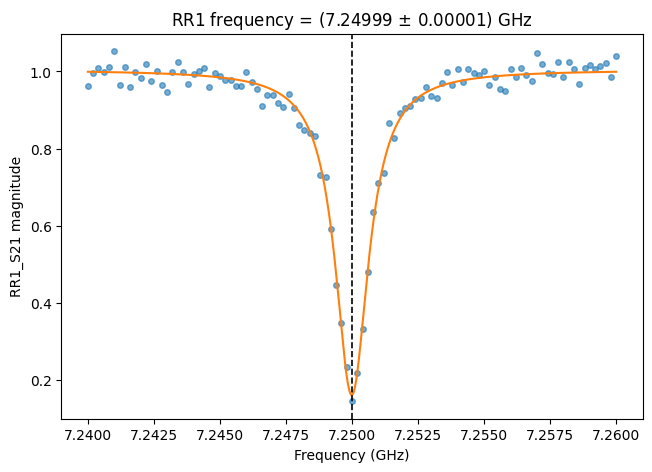

In [8]:
# Cell A2 — resonator spectroscopy: batched steady-state sweep of the cavity
f_r_true = 7.250          # GHz   readout resonator frequency
kappa = 0.0015            # GHz   resonator linewidth (FWHM)
epsilon = 0.0002          # GHz   weak probe amplitude (~0.02 photons on resonance)

dims_res = {0: 6}                                     # plenty for a weak probe
res_collapse = [np.sqrt(2.0 * np.pi * kappa) * a]     # photon loss at rate kappa
res_vacuum = cudaq.State.from_data(
    np.array([1.0, 0.0, 0.0, 0.0, 0.0, 0.0], dtype=np.complex128))

res_freqs = np.linspace(7.240, 7.260, 101)            # GHz probe sweep
res_hams = [2.0 * np.pi * ((f_r_true - fp) * N + (epsilon / 2.0) * (a + a_dag))
            for fp in res_freqs]

# ring up to steady state: 2000 ns is many resonator lifetimes (photon lifetime 1/(2*pi*kappa) ~ 106 ns)
t0 = time.perf_counter()
res_results = cudaq.evolve(res_hams, dims_res,
                           Schedule(np.linspace(0.0, 2000.0, 21), ["t"]),
                           res_vacuum,
                           collapse_operators=[res_collapse] * len(res_hams),
                           observables=[N],
                           store_intermediate_results=cudaq.IntermediateResultSave.NONE,
                           integrator=RungeKuttaIntegrator(order=4, max_step_size=1.0))
n_ss = np.array([r.expectation_values()[-1][0].expectation() for r in res_results])
print(f"{len(res_freqs)} simulations in one batched evolve call: "
      f"{time.perf_counter() - t0:.0f} s")

# absorbed probe power -> transmission dip, plus analog measurement noise
s21 = 1.0 - 0.85 * (n_ss / np.max(n_ss))
s21_meas = s21 + rng.normal(0.0, 0.02, size=s21.shape)

res_guess = [1.0, 0.85, res_freqs[np.argmin(s21_meas)], 0.001]
res_popt, res_pcov = curve_fit(lorentzian_dip, res_freqs, s21_meas, p0=res_guess)
f_r_fit = res_popt[2]
f_r_err = np.sqrt(np.diag(res_pcov))[2]
kappa_fit_MHz = 2.0 * abs(res_popt[3]) * 1e3
print(f"fitted f_r = ({f_r_fit:.5f} +/- {f_r_err:.5f}) GHz   (truth {f_r_true:.4f} GHz)")
print(f"fitted linewidth kappa = {kappa_fit_MHz:.2f} MHz   (truth {kappa * 1e3:.2f} MHz)")

rf_fine = np.linspace(res_freqs[0], res_freqs[-1], 800)
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(res_freqs, s21_meas, s=16, alpha=0.6)
ax.plot(rf_fine, lorentzian_dip(rf_fine, *res_popt), color="tab:orange")
ax.axvline(f_r_fit, color="black", linestyle="--", linewidth=1.2)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("RR1_S21 magnitude")
ax.set_title(f"RR1 frequency = ({f_r_fit:.5f} $\\pm$ {f_r_err:.5f}) GHz")
fig.savefig(f"{plot_dir}/resonator_spectroscopy.png", dpi=150, bbox_inches="tight")
plt.show()

### A.3 · Qubit spectroscopy — the three-level transmon

With the resonator found, we hunt the qubit. A transmon is a weakly *anharmonic* ladder —
we keep three levels — and in the frame rotating at the drive frequency $f_d$:

$$H/\hbar = 2\pi\,(f_{01} - f_d)\,\hat N \;+\; 2\pi\,\frac{\alpha}{2}\,\hat N(\hat N - 1)
\;+\; 2\pi\,\frac{\Omega}{2}\,(\hat a + \hat a^\dagger),$$

plus $T_1$ relaxation and pure dephasing as collapse operators. The sweep is again one
batched `evolve` (121 Hamiltonians). What a lab plot shows is **readout contrast**, not
population: exciting the qubit pulls the dispersive-readout signal *down*, so the qubit is a
dip at $f_{01}$, power-broadened by the strong probe. The strong probe also *shifts* the
apparent line by a few MHz (an AC-Stark shift), so the fitted $f_{01}$ can sit slightly off
the true value — Ramsey (A.6) is the precision tool that pins the frequency exactly.

Things to try, then re-ask the agent: `omega_probe = 0.10` makes the two-photon
$f_{02}/2$ dip at 4.690 GHz grow in (**`AMP_TOO_HIGH`**); sweeping `freqs` over
`4.20–4.50` GHz misses the qubit entirely (**`NO_SIGNAL`**).

121 simulations in one batched evolve call: 203 s
fitted f01 = (4.807 +/- 0.0022) GHz   (truth 4.8000 GHz)


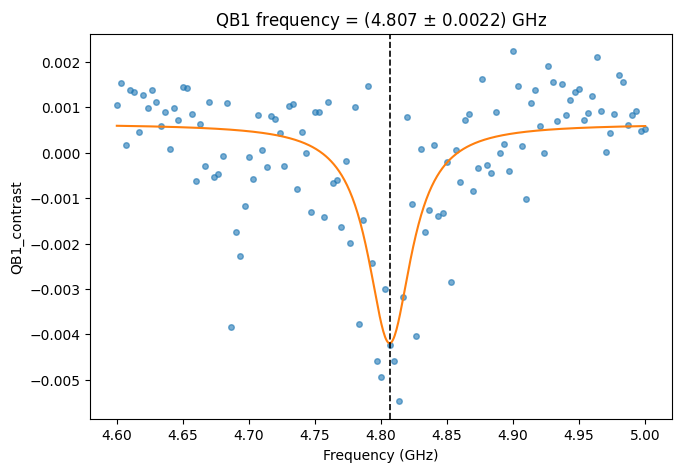

In [9]:
# Cell A3 — qubit spectroscopy: find the qubit through its readout-contrast dip
dimensions = {0: 3}                  # the transmon keeps 3 levels in the model
NN1 = a_dag * a_dag * a * a          # N(N-1), the anharmonic-ladder term

collapse_3lvl = [np.sqrt(1.0 / T1) * a, np.sqrt(2.0 * gamma_phi) * N]

ground = cudaq.State.from_data(np.array([1.0, 0.0, 0.0], dtype=np.complex128))

pulse_ns = 250.0
spec_schedule = Schedule(np.linspace(0.0, pulse_ns, 26), ["t"])
integrator = RungeKuttaIntegrator(order=4, max_step_size=0.2)

def spectroscopy_hamiltonian(f_drive, omega_drive):
    """Rotating-frame transmon Hamiltonian for one probe frequency/amplitude."""
    detuning = f01_true - f_drive
    return 2.0 * np.pi * (detuning * N + (alpha / 2.0) * NN1
                          + (omega_drive / 2.0) * (a + a_dag))

def sweep_excited_population(freq_list, omega_list):
    """One batched evolve — the GPU integrates every sweep point at once.

    Returns P(excited) = 1 - P(|0>) after the pulse; on a 3-level system
    <N> = P1 + 2*P2 and <N(N-1)> = 2*P2, so P(excited) = <N> - <N(N-1)>/2.
    """
    hams = [spectroscopy_hamiltonian(f, w) for f, w in zip(freq_list, omega_list)]
    results = cudaq.evolve(hams, dimensions, spec_schedule, ground,
                           collapse_operators=[collapse_3lvl] * len(hams),
                           observables=[N, NN1],
                           store_intermediate_results=cudaq.IntermediateResultSave.NONE,
                           integrator=integrator)
    populations = []
    for res in results:
        final = res.expectation_values()[-1]
        populations.append(final[0].expectation() - 0.5 * final[1].expectation())
    return np.array(populations)

freqs = np.linspace(4.60, 5.00, 121)     # GHz
omega_probe = 0.050                      # GHz  (strong probe -> power-broadened line)

t0 = time.perf_counter()
p_exc = sweep_excited_population(freqs, np.full_like(freqs, omega_probe))
print(f"{len(freqs)} simulations in one batched evolve call: "
      f"{time.perf_counter() - t0:.0f} s")

# What a real lab plot shows is not population but READOUT CONTRAST — the raw
# dispersive-readout signal (arbitrary units). Exciting the qubit pulls the
# contrast DOWN, so the qubit appears as a dip.
contrast_ground = 0.0012                 # readout signal with the qubit in |0>
contrast_excited = -0.0052               # readout signal with the qubit excited
contrast = contrast_ground + (contrast_excited - contrast_ground) * p_exc
contrast_meas = contrast + rng.normal(0.0, 0.0005, size=contrast.shape)

guess = [contrast_ground, 0.006, freqs[np.argmin(contrast_meas)], 0.05]
spec_popt, spec_pcov = curve_fit(lorentzian_dip, freqs, contrast_meas, p0=guess)
f01_fit = spec_popt[2]
f01_err = np.sqrt(np.diag(spec_pcov))[2]
print(f"fitted f01 = ({f01_fit:.3f} +/- {f01_err:.4f}) GHz   (truth {f01_true:.4f} GHz)")

f_fine = np.linspace(freqs[0], freqs[-1], 600)
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(freqs, contrast_meas, s=16, alpha=0.6)
ax.plot(f_fine, lorentzian_dip(f_fine, *spec_popt), color="tab:orange")
ax.axvline(f01_fit, color="black", linestyle="--", linewidth=1.2)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("QB1_contrast")
ax.set_title(f"QB1 frequency = ({f01_fit:.3f} $\\pm$ {f01_err:.4f}) GHz")
fig.savefig(f"{plot_dir}/qubit_spectroscopy.png", dpi=150, bbox_inches="tight")
plt.show()

### A.4 · Rabi oscillation — calibrate the $\pi$ pulse

Park the drive exactly on resonance ($f_d = f_{01}$): the detuning term vanishes and the
population flops sinusoidally at the drive amplitude $\Omega$,
$P_1(t) \approx \tfrac12\left(1 - \cos(2\pi\Omega t)\right)$. The first maximum is the
**$\pi$-pulse duration** $t_\pi = 1/(2\Omega)$ — the single most-used number in the control
stack. The anharmonicity term is doing quiet work: it keeps the drive from climbing past
$\lvert 1\rangle$ into $\lvert 2\rangle$ (the printed *leakage* checks this). We fit a
decaying cosine; the decay constant is barely constrained over 400 ns, so it is bounded
loosely and not reported. This plot is a good one for a **Q4 fit-reliability** question.

max leakage into |2>: 0.0011
fitted f_rabi = 9.987 MHz   (truth 10.000 MHz)
fitted t_pi   = 50.07 ns    (truth 50.00 ns)


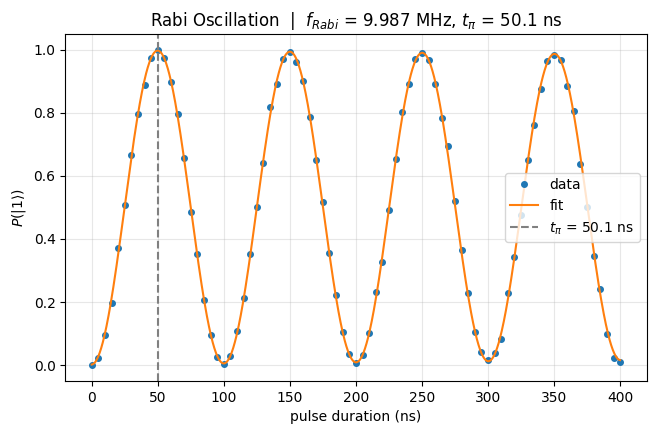

In [10]:
# Cell A4 — Rabi oscillation: drive on resonance, calibrate the pi pulse
omega_rabi = 0.010        # GHz drive amplitude -> 10 MHz Rabi frequency

rabi_hamiltonian = 2.0 * np.pi * ((alpha / 2.0) * NN1
                                  + (omega_rabi / 2.0) * (a + a_dag))

def proj1_matrix(dimension: int, **kwargs):
    mat = np.zeros((dimension, dimension), dtype=np.complex128)
    mat[1, 1] = 1.0
    return mat

def proj2_matrix(dimension: int, **kwargs):
    mat = np.zeros((dimension, dimension), dtype=np.complex128)
    mat[2, 2] = 1.0
    return mat

operators.define("proj1", [0], proj1_matrix)
operators.define("proj2", [0], proj2_matrix)
proj1 = operators.instantiate("proj1", [0])
proj2 = operators.instantiate("proj2", [0])

rabi_times = np.linspace(0.0, 400.0, 801)
result = cudaq.evolve(rabi_hamiltonian, dimensions, Schedule(rabi_times, ["t"]),
                      InitialState.ZERO,
                      collapse_operators=collapse_3lvl,
                      observables=[proj1, proj2],
                      store_intermediate_results=cudaq.IntermediateResultSave.EXPECTATION_VALUE,
                      integrator=integrator)

exp_vals = result.expectation_values()          # indexed [time step][observable]
rabi_P1 = np.array([step[0].expectation() for step in exp_vals])
rabi_P2 = np.array([step[1].expectation() for step in exp_vals])
print(f"max leakage into |2>: {np.max(rabi_P2):.4f}")

pick = np.linspace(0, len(rabi_times) - 1, 81).astype(int)
rabi_t_meas = rabi_times[pick]
rabi_P1_meas = measure(rabi_P1[pick])

def rabi_model(t, offset, amplitude, f_rabi, phi, tau):
    return offset + amplitude * np.cos(2.0 * np.pi * f_rabi * t + phi) * np.exp(-t / tau)

# tau is barely constrained over 400 ns (T1 and T2* are 25-60x longer), so it
# is bounded loosely and not reported as a calibrated value.
rabi_popt, _ = curve_fit(rabi_model, rabi_t_meas, rabi_P1_meas,
                         p0=[0.5, -0.5, 0.010, 0.0, 20000.0],
                         bounds=([0.0, -1.0, 0.001, -np.pi, 1000.0],
                                 [1.0, 1.0, 0.100, np.pi, 1e6]))
f_rabi_fit = rabi_popt[2]
t_pi = 1.0 / (2.0 * f_rabi_fit)
print(f"fitted f_rabi = {f_rabi_fit * 1e3:.3f} MHz   (truth {omega_rabi * 1e3:.3f} MHz)")
print(f"fitted t_pi   = {t_pi:.2f} ns    (truth {1.0 / (2.0 * omega_rabi):.2f} ns)")

t_fine = np.linspace(0.0, 400.0, 1001)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(rabi_t_meas, rabi_P1_meas, "o", markersize=4, label="data")
ax.plot(t_fine, rabi_model(t_fine, *rabi_popt), "-", label="fit")
ax.axvline(t_pi, linestyle="--", color="gray", label=f"$t_\\pi$ = {t_pi:.1f} ns")
ax.set_xlabel("pulse duration (ns)")
ax.set_ylabel(r"$P(|1\rangle)$")
ax.set_title(f"Rabi Oscillation  |  $f_{{Rabi}}$ = {f_rabi_fit * 1e3:.3f} MHz, "
             f"$t_\\pi$ = {t_pi:.1f} ns")
ax.legend()
ax.grid(alpha=0.3)
fig.savefig(f"{plot_dir}/rabi_oscillation.png", dpi=150, bbox_inches="tight")
plt.show()

### A.5 · $T_1$ relaxation — how long does $\lvert 1\rangle$ live?

Flip the qubit to $\lvert 1\rangle$ (on hardware: one calibrated $\pi$ pulse), wait a variable
delay, measure. Energy leaks to the environment and $P_1(t) = e^{-t/T_1}$. In the master
equation the *collapse operator is the experiment*: $\sqrt{1/T_1}\,\hat a$, with a zero
Hamiltonian in the rotating frame — nothing coherent happens, the qubit just sits and decays.
Two levels suffice (no drive, so $\lvert 2\rangle$ is never reached). On real hardware $T_1$
drifts by the hour — the reason calibration is a loop, not a one-time setup. For the
**dying-qubit** scenario, set `T1 = 3000` *and* `T2_star = 4000` in Cell A1 and re-run
(keep $T_2^* \le 2T_1$, or the pure-dephasing rate turns negative).

fitted T1 = 24.96 us   (truth 25.00 us)


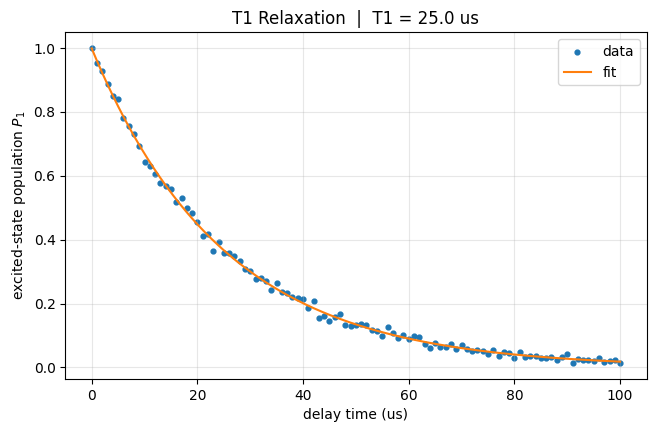

In [11]:
# Cell A5 — T1 relaxation: prepare |1>, wait, watch the energy leak away
dims_qubit = {0: 2}       # no drive -> nothing reaches |2>, two levels suffice

t1_hamiltonian = 2.0 * np.pi * 0.0 * operators.number(0)
t1_collapse = [np.sqrt(1.0 / T1) * operators.annihilate(0)]
excited = cudaq.State.from_data(np.array([0.0, 1.0], dtype=np.complex128))

t1_times = np.linspace(0.0, 100000.0, 101)       # delays from 0 to 100 us
result = cudaq.evolve(t1_hamiltonian, dims_qubit, Schedule(t1_times, ["t"]),
                      excited,
                      collapse_operators=t1_collapse,
                      observables=[operators.number(0)],     # <N> = P1 on a qubit
                      store_intermediate_results=cudaq.IntermediateResultSave.EXPECTATION_VALUE,
                      integrator=RungeKuttaIntegrator(order=4, max_step_size=100.0))

t1_P1 = np.array([step[0].expectation() for step in result.expectation_values()])
t1_P1_meas = measure(t1_P1)

def decay_model(t, amplitude, t1, offset):
    return amplitude * np.exp(-t / t1) + offset

t1_popt, _ = curve_fit(decay_model, t1_times, t1_P1_meas, p0=[1.0, 20000.0, 0.0])
T1_fit = t1_popt[1]
print(f"fitted T1 = {T1_fit / 1e3:.2f} us   (truth {T1 / 1e3:.2f} us)")

t_fine = np.linspace(0.0, 100000.0, 500)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.scatter(t1_times / 1e3, t1_P1_meas, s=12, label="data")
ax.plot(t_fine / 1e3, decay_model(t_fine, *t1_popt), "-", color="C1", label="fit")
ax.set_xlabel("delay time (us)")
ax.set_ylabel("excited-state population $P_1$")
ax.set_title(f"T1 Relaxation  |  T1 = {T1_fit / 1e3:.1f} us")
ax.legend()
ax.grid(alpha=0.3)
fig.savefig(f"{plot_dir}/t1_relaxation.png", dpi=150, bbox_inches="tight")
plt.show()

### A.6 · Ramsey fringes — frequency error and $T_2^*$

The precision tool: two $\pi/2$ pulses separated by a variable delay. We deliberately detune
the drive from the qubit by $\Delta f = 0.4$ MHz, so the qubit accumulates phase
$2\pi\,\Delta f\,t$ during the free evolution and the population fringes at *exactly the
detuning*, with the envelope decaying as $T_2^*$:

$$P_1(t) = \tfrac12\left(1 + \cos(2\pi\,\Delta f\,t)\,e^{-t/T_2^*}\right).$$

Simulation shortcut (honestly disclosed): the $\pi/2$ pulses are ideal — the free evolution
starts in $\lvert + \rangle = (\lvert 0\rangle + \lvert 1\rangle)/\sqrt2$, and the second
$\pi/2$ is the mapping $P_1 = (1 + \langle\sigma_x\rangle)/2$. Two calibration numbers in one
plot: the fringe frequency is the frequency error (how you fine-tune $f_{01}$ far beyond the
spectroscopy linewidth), and the envelope is $T_2^*$ — phase coherence, the resource
entanglement actually consumes ($T_2^* \le 2T_1$).

fitted detuning = 0.4005 MHz   (truth 0.4000 MHz)
fitted T2*      = 9.86 us       (truth 10.00 us)


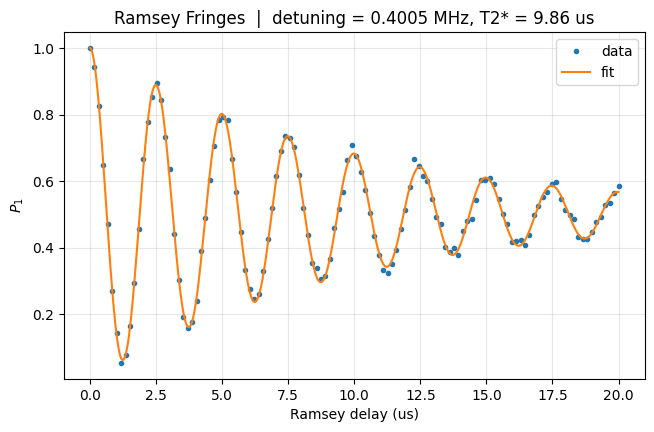

In [12]:
# Cell A6 — Ramsey fringes: detune on purpose, read the frequency error back
delta_ramsey = 0.0004     # GHz — the drive is deliberately 0.4 MHz off the qubit

ramsey_hamiltonian = 2.0 * np.pi * delta_ramsey * operators.number(0)
ramsey_collapse = [np.sqrt(1.0 / T1) * operators.annihilate(0),
                   np.sqrt(2.0 * gamma_phi) * operators.number(0)]
plus = cudaq.State.from_data(np.array([1.0, 1.0], dtype=np.complex128) / np.sqrt(2.0))

ramsey_times = np.linspace(0.0, 20000.0, 2001)   # delays from 0 to 20 us
result = cudaq.evolve(ramsey_hamiltonian, dims_qubit, Schedule(ramsey_times, ["t"]),
                      plus,
                      collapse_operators=ramsey_collapse,
                      observables=[spin.x(0)],
                      store_intermediate_results=cudaq.IntermediateResultSave.EXPECTATION_VALUE)

# the second pi/2 pulse maps the coherence onto population: P1 = (1 + <x>)/2
exp_x = np.array([step[0].expectation() for step in result.expectation_values()])
ramsey_P1 = (1.0 + exp_x) / 2.0

pick = np.linspace(0, len(ramsey_times) - 1, 120).astype(int)
ramsey_t_meas = ramsey_times[pick]
ramsey_P1_meas = measure(ramsey_P1[pick])

def ramsey_model(t, offset, amplitude, freq, phase, T2):
    return offset + amplitude * np.cos(2.0 * np.pi * freq * t + phase) * np.exp(-t / T2)

ramsey_popt, _ = curve_fit(ramsey_model, ramsey_t_meas, ramsey_P1_meas,
                           p0=[0.5, 0.5, 0.0004, 0.0, 10000.0])
detuning_fit = ramsey_popt[2]
T2_fit = ramsey_popt[4]
print(f"fitted detuning = {detuning_fit * 1e3:.4f} MHz   (truth {delta_ramsey * 1e3:.4f} MHz)")
print(f"fitted T2*      = {T2_fit / 1e3:.2f} us       (truth {T2_star / 1e3:.2f} us)")

t_fine = np.linspace(0.0, 20000.0, 1000)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(ramsey_t_meas / 1e3, ramsey_P1_meas, "o", markersize=3, label="data")
ax.plot(t_fine / 1e3, ramsey_model(t_fine, *ramsey_popt), "-", label="fit")
ax.set_xlabel("Ramsey delay (us)")
ax.set_ylabel("$P_1$")
ax.set_title(f"Ramsey Fringes  |  detuning = {detuning_fit * 1e3:.4f} MHz, "
             f"T2* = {T2_fit / 1e3:.2f} us")
ax.legend()
ax.grid(alpha=0.3)
fig.savefig(f"{plot_dir}/ramsey_fringes.png", dpi=150, bbox_inches="tight")
plt.show()

### A.7 · Exercise — your turn to query the agent

You now have five fresh plots from your own simulations (A.2–A.6) — plus the Part V
drift plot — sitting in `calibration_plots/`. Pick one, write your own QCalEval-style question
(any of Q1–Q6 from Part I — the Rabi plot with a Q4 *fit reliability* question is a nice
one), and send it with the `ask_agent(...)` helper from Cell 4. Then go further: change a
parameter in one of the appendix cells (see the broken-experiment recipes in Part VI),
regenerate the plot, and check whether the agent catches what you broke.

In [13]:
# Cell A7 — EXERCISE: pick a plot, write your own prompt, ask the agent

my_plot = "calibration_plots/..."       # TODO: pick a plot from calibration_plots/

my_question = (
    "..."                               # TODO: write your QCalEval-style question (Q1-Q6)
)

# TODO: uncomment once my_plot and my_question are filled in
# print(ask_agent(my_plot, my_question))